In [1]:
import pandas as pd

In [5]:
df = pd.read_csv(r'C:\Users\xenof\OneDrive\Рабочий стол\project\SampleSuperstore.csv', encoding='latin1')

In [6]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [7]:
df.shape

(9994, 13)

In [8]:
df.columns.tolist()

['Ship Mode',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Category',
 'Sub-Category',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [9]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [10]:
df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1.7 MB


In [12]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [13]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [14]:
import sqlite3

In [15]:
conn = sqlite3.connect('superstore.db')

In [16]:
df.to_sql('orders', conn, if_exists='replace', index=False)

9994

In [17]:
pd.read_sql_query("SELECT * FROM orders LIMIT 5", conn)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [18]:
query = """
select city, sum(sales) as total_sales
from orders
group by city
order by total_sales desc
limit 5
"""
result = pd.read_sql_query(query, conn)
result

,City,total_sales
0,New York City,256368.161
1,Los Angeles,175851.341
2,Seattle,119540.742
3,San Francisco,112669.092
4,Philadelphia,109077.013


In [19]:
query = """
select category, sum(profit) as total_profit
from orders
group by category
order by total_profit desc
limit 3;
"""
result = pd.read_sql_query(query, conn)
result

,Category,total_profit
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


In [20]:
query = """
select region, avg(sales) as avg_sales
from orders
group by region
order by avg_sales desc;
"""
result = pd.read_sql_query(query, conn)
result

,Region,avg_sales
0,South,241.803645
1,East,238.336110
2,West,226.493233
3,Central,215.772661


In [24]:
query = """
select city, sum(profit) as sum_profit
from orders
group by city
having sum_profit < 0
order by sum_profit asc;
"""
result = pd.read_sql_query(query, conn)
result

,City,sum_profit
0,Philadelphia,-13837.7674
1,Houston,-10153.5485
2,San Antonio,-7299.0502
3,Lancaster,-7239.0684
4,Chicago,-6654.5688
...,...,...
111,Ormond Beach,-1.9656
112,Pensacola,-1.4760
113,Elyria,-1.3984
114,Altoona,-1.1835


In [25]:
query = """
select segment, sum(sales) as total_sales
from orders
group by segment
order by total_sales desc;
"""
result = pd.read_sql_query(query, conn)
result

,Segment,total_sales
0,Consumer,1.161401e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


In [27]:
query = """
select category, avg(discount) as avg_discount
from orders
group by category
order by avg_discount desc;
"""
result = pd.read_sql_query(query, conn)
result

,Category,avg_discount
0,Furniture,0.173923
1,Office Supplies,0.157285
2,Technology,0.132323


In [31]:
query = """
select region, "ship mode", count(sales) as count_sales
from orders
group by region, "ship mode"
order by region;
"""
result = pd.read_sql_query(query, conn)
result

,Region,Ship Mode,count_sales
0,Central,First Class,299
1,Central,Same Day,120
2,Central,Second Class,465
3,Central,Standard Class,1439
4,East,First Class,490
5,East,Same Day,155
6,East,Second Class,530
7,East,Standard Class,1673
8,South,First Class,234
9,South,Same Day,83


In [34]:
query = """
select "sub-category", sum(profit) as sum_profit
from orders
group by "sub-category"
order by sum_profit desc
limit 5;
"""
result = pd.read_sql_query(query, conn)
result

,Sub-Category,sum_profit
0,Copiers,55617.8249
1,Phones,44515.7306
2,Accessories,41936.6357
3,Paper,34053.5693
4,Binders,30221.7633


In [38]:
query = """
select "sub-category", sum(profit) as sum_profit
from orders
group by "sub-category"
having sum_profit < 0
order by sum_profit asc;
"""
result = pd.read_sql_query(query, conn)
result

,Sub-Category,sum_profit
0,Tables,-17725.4811
1,Bookcases,-3472.5560
2,Supplies,-1189.0995


In [52]:
query = """
with city_sales as (
select region, city, sum(sales) as sum_sales
from orders
group by region, city
),
city_ranked as (
select region, city, sum_sales,
row_number () over (
partition by region
order by sum_sales desc
) as row_number_of_city
from city_sales
) 
select region, city, sum_sales, row_number_of_city
from city_ranked
where row_number_of_city <= 3;
"""
result = pd.read_sql_query(query, conn)
result

,region,city,sum_sales,row_number_of_city
0,Central,Houston,64504.7604,1
1,Central,Chicago,48539.5410,2
2,Central,Detroit,42446.9440,3
3,East,New York City,256368.1610,1
4,East,Philadelphia,109077.0130,2
5,East,Newark,28576.1190,3
6,South,Jacksonville,44713.1830,1
7,South,Atlanta,17197.8400,2
8,South,Springfield,16628.5300,3
9,West,Los Angeles,175851.3410,1


In [53]:
query = """
CREATE TABLE customers AS
SELECT DISTINCT "Customer Name", City, State, Region, Segment
FROM orders;
"""
cursor = conn.cursor()
cursor.execute(query)

In [54]:
pd.read_sql_query("SELECT * FROM customers LIMIT 5", conn)

,"""Customer Name""",City,State,Region,Segment
0,Customer Name,Henderson,Kentucky,South,Consumer
1,Customer Name,Los Angeles,California,West,Corporate
2,Customer Name,Fort Lauderdale,Florida,South,Consumer
3,Customer Name,Los Angeles,California,West,Consumer
4,Customer Name,Concord,North Carolina,South,Consumer


In [56]:
pd.read_sql_query('SELECT "Customer Name" FROM orders LIMIT 5', conn)

,"""Customer Name"""
0,Customer Name
1,Customer Name
2,Customer Name
3,Customer Name
4,Customer Name


In [57]:
query = """
CREATE TABLE categories AS
SELECT DISTINCT Category, "Sub-Category"
FROM orders;
"""
cursor = conn.cursor()
cursor.execute(query)

In [58]:
pd.read_sql_query("SELECT * FROM categories LIMIT 10", conn)

,Category,Sub-Category
0,Furniture,Bookcases
1,Furniture,Chairs
2,Office Supplies,Labels
3,Furniture,Tables
4,Office Supplies,Storage
5,Furniture,Furnishings
6,Office Supplies,Art
7,Technology,Phones
8,Office Supplies,Binders
9,Office Supplies,Appliances


In [59]:
query = """
select c.category, c."sub-category", sum(sales) as sum_sales
from orders o
inner join categories c on o."sub-category" = c."sub-category"
group by c.category, c."sub-category"
order by sum_sales;
"""
result = pd.read_sql_query(query, conn)
result

,Category,Sub-Category,sum_sales
0,Office Supplies,Fasteners,3024.2800
1,Office Supplies,Labels,12486.3120
2,Office Supplies,Envelopes,16476.4020
3,Office Supplies,Art,27118.7920
4,Office Supplies,Supplies,46673.5380
5,Office Supplies,Paper,78479.2060
6,Furniture,Furnishings,91705.1640
7,Office Supplies,Appliances,107532.1610
8,Furniture,Bookcases,114879.9963
9,Technology,Copiers,149528.0300


In [60]:
query = """
CREATE TABLE regions AS
SELECT DISTINCT Region, State
FROM orders;
"""
cursor = conn.cursor()
cursor.execute(query)

In [61]:
pd.read_sql_query("SELECT * FROM regions LIMIT 10", conn)

,Region,State
0,South,Kentucky
1,West,California
2,South,Florida
3,South,North Carolina
4,West,Washington
5,Central,Texas
6,Central,Wisconsin
7,West,Utah
8,Central,Nebraska
9,East,Pennsylvania


In [63]:
query = """
select r.region, sum(sales) as sum_sales
from orders o
inner join regions r on o.state = r.state
group by r.region
order by sum_sales desc;
"""
result = pd.read_sql_query(query, conn)
result

,Region,sum_sales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


In [64]:
category_sales = pd.read_sql_query("""
SELECT Category, SUM(Sales) as total_sales
FROM orders
GROUP BY Category
ORDER BY total_sales DESC
""", conn)
category_sales

,Category,total_sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


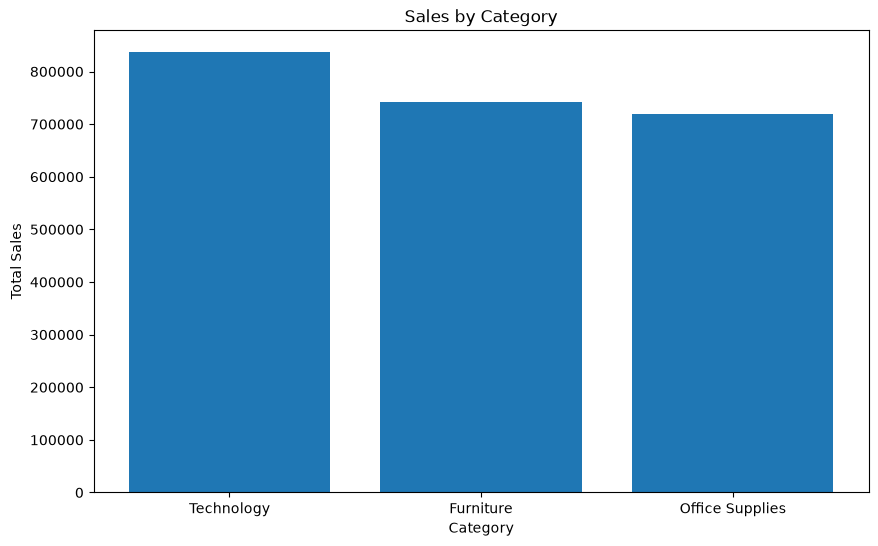

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(category_sales['Category'], category_sales['total_sales'])
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

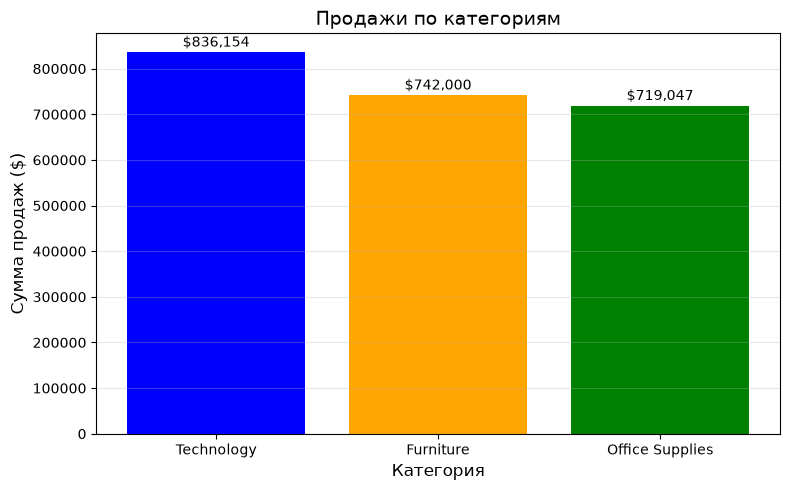

In [67]:
plt.figure(figsize=(8, 5))
bars = plt.bar(category_sales['Category'], category_sales['total_sales'], 
               color=['blue', 'orange', 'green'])

plt.title('Продажи по категориям', fontsize=14)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Сумма продаж ($)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5000,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

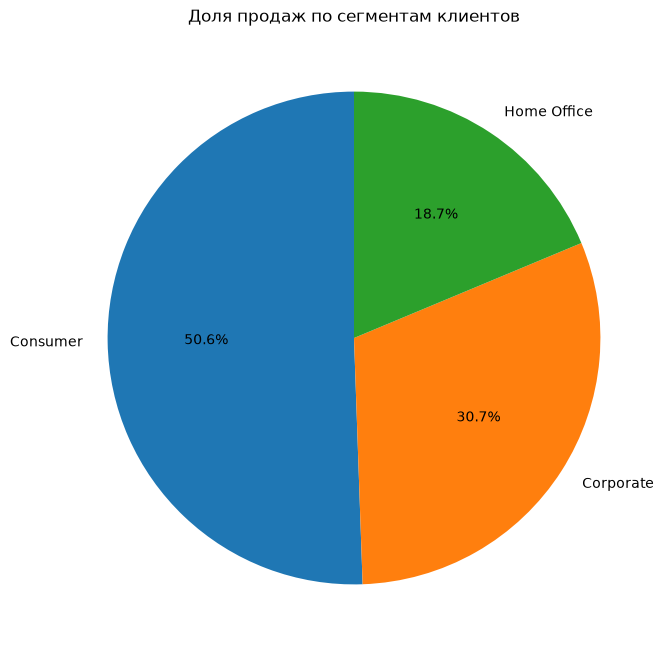

In [68]:
segment_sales = pd.read_sql_query("""
SELECT Segment, SUM(Sales) as total_sales
FROM orders
GROUP BY Segment
""", conn)

plt.figure(figsize=(8, 8))
plt.pie(segment_sales['total_sales'], 
        labels=segment_sales['Segment'], 
        autopct='%1.1f%%',
        startangle=90)
plt.title('Доля продаж по сегментам клиентов')
plt.show()

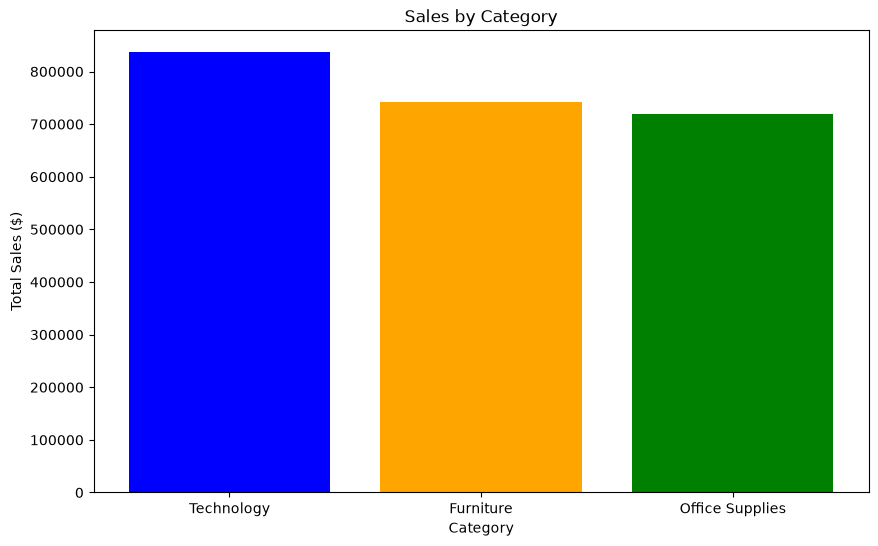

In [69]:
plt.figure(figsize=(10, 6))
plt.bar(category_sales['Category'], category_sales['total_sales'], color=['blue', 'orange', 'green'])
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.savefig('sales_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

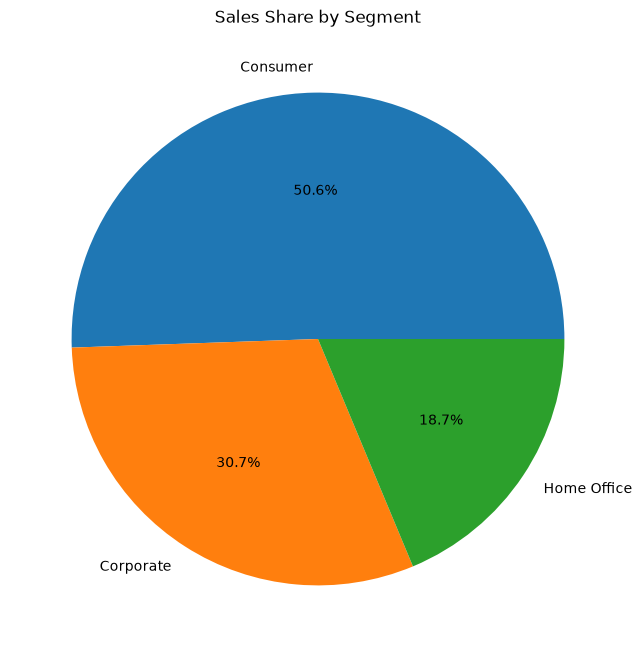

In [70]:
plt.figure(figsize=(8, 8))
plt.pie(segment_sales['total_sales'], labels=segment_sales['Segment'], autopct='%1.1f%%')
plt.title('Sales Share by Segment')
plt.savefig('sales_share_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

In [71]:
import os
os.getcwd()

'C:\\Users\\xenof\\OneDrive\\Рабочий стол\\project'

In [74]:
import os
os.makedirs('images', exist_ok=True)

In [75]:
import os
os.listdir()

['.ipynb_checkpoints',
 'images',
 'sales_by_category.png',
 'sales_share_by_segment.png',
 'SampleSuperstore.csv',
 'superstore.db',
 'Untitled.ipynb']

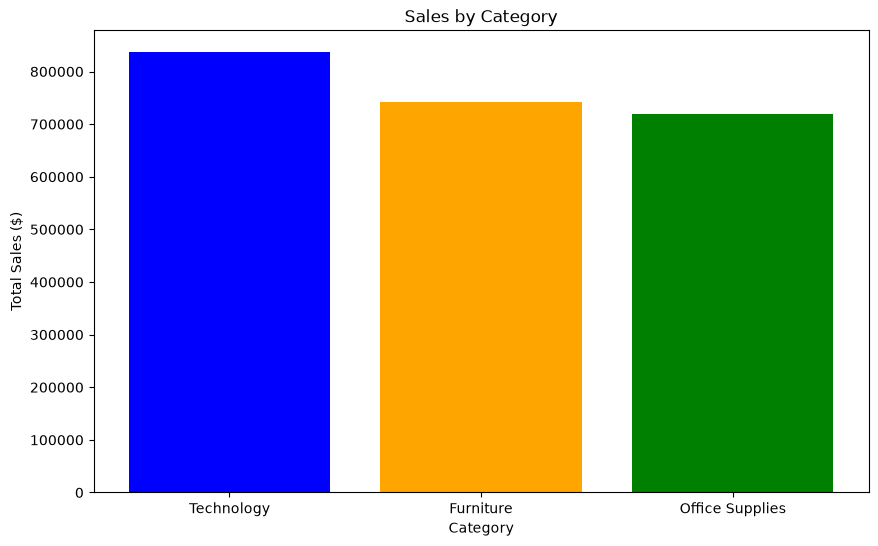

In [76]:
plt.figure(figsize=(10, 6))
plt.bar(category_sales['Category'], category_sales['total_sales'], color=['blue', 'orange', 'green'])
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.savefig('images/sales_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [77]:
subcategory_data = pd.read_sql_query("""
SELECT "Sub-Category", AVG(Discount) as avg_discount, SUM(Profit) as total_profit
FROM orders
GROUP BY "Sub-Category"
""", conn)

subcategory_data.head(10)

,Sub-Category,avg_discount,total_profit
0,Accessories,0.078452,41936.6357
1,Appliances,0.166524,18138.0054
2,Art,0.074874,6527.7870
3,Binders,0.372292,30221.7633
4,Bookcases,0.211140,-3472.5560
5,Chairs,0.170178,26590.1663
6,Copiers,0.161765,55617.8249
7,Envelopes,0.080315,6964.1767
8,Fasteners,0.082028,949.5182
9,Furnishings,0.138349,13059.1436


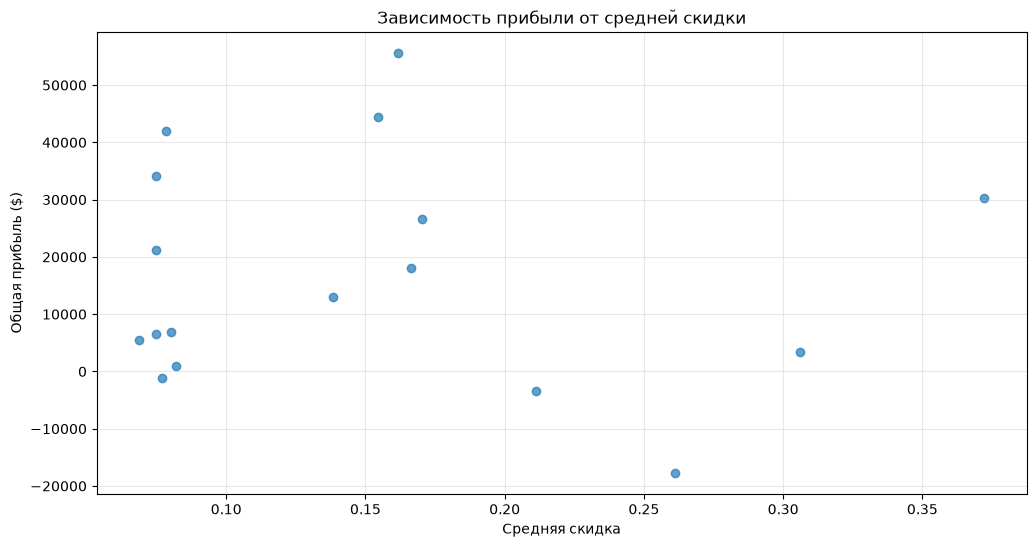

In [78]:
plt.figure(figsize=(12, 6))
plt.scatter(subcategory_data['avg_discount'], subcategory_data['total_profit'], alpha=0.7)

plt.title('Зависимость прибыли от средней скидки')
plt.xlabel('Средняя скидка')
plt.ylabel('Общая прибыль ($)')
plt.grid(True, alpha=0.3)
plt.show()

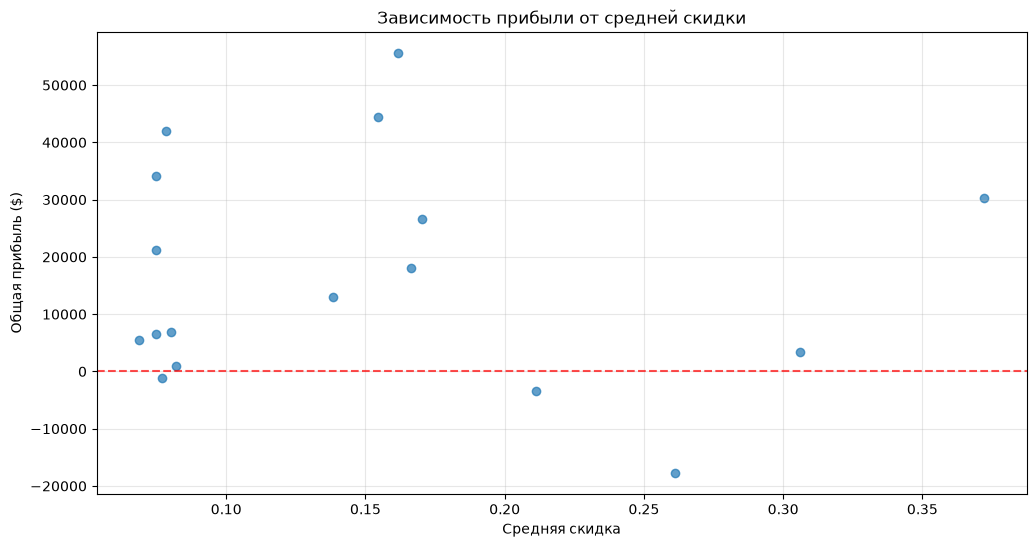

In [79]:
plt.figure(figsize=(12, 6))
plt.scatter(subcategory_data['avg_discount'], subcategory_data['total_profit'], alpha=0.7)

plt.title('Зависимость прибыли от средней скидки')
plt.xlabel('Средняя скидка')
plt.ylabel('Общая прибыль ($)')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)

plt.show()

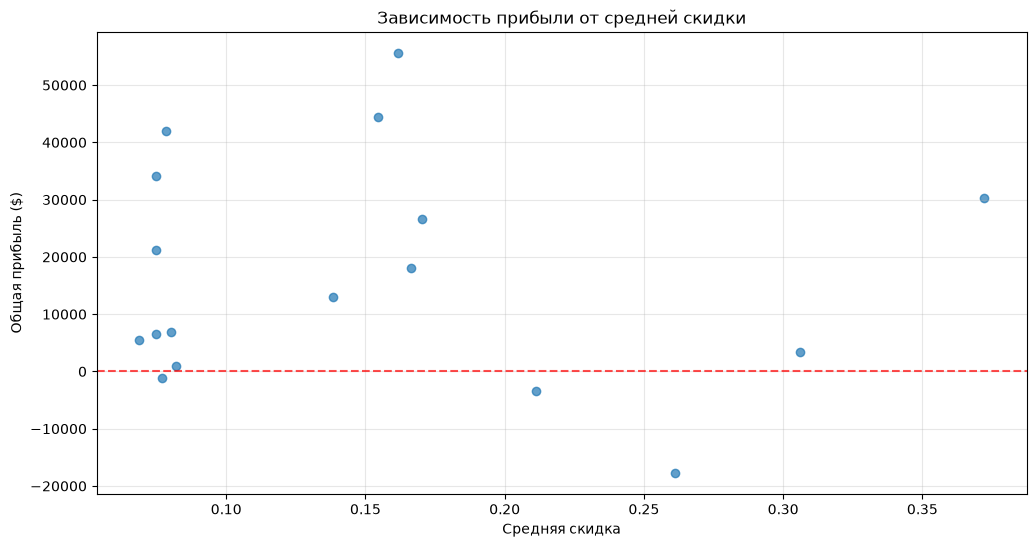

In [85]:
plt.figure(figsize=(12, 6))
plt.scatter(subcategory_data['avg_discount'], subcategory_data['total_profit'], alpha=0.7)

plt.title('Зависимость прибыли от средней скидки')
plt.xlabel('Средняя скидка')
plt.ylabel('Общая прибыль ($)')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)

plt.savefig('images/discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()

In [86]:
top_cities = pd.read_sql_query("""
SELECT City, SUM(Sales) as total_sales
FROM orders
GROUP BY City
ORDER BY total_sales DESC
LIMIT 10
""", conn)

print(top_cities.shape)
top_cities.head()

(10, 2)


,City,total_sales
0,New York City,256368.161
1,Los Angeles,175851.341
2,Seattle,119540.742
3,San Francisco,112669.092
4,Philadelphia,109077.013


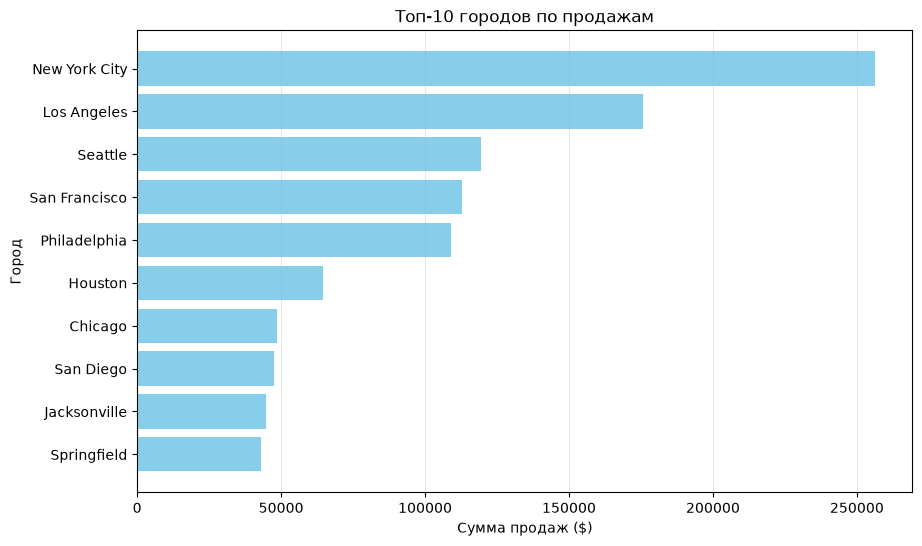

In [87]:
plt.figure(figsize=(10, 6))
plt.barh(top_cities['City'], top_cities['total_sales'], color='skyblue')

plt.title('Топ-10 городов по продажам')
plt.xlabel('Сумма продаж ($)')
plt.ylabel('Город')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

plt.savefig('images/top_cities.png', dpi=150, bbox_inches='tight')
plt.show()

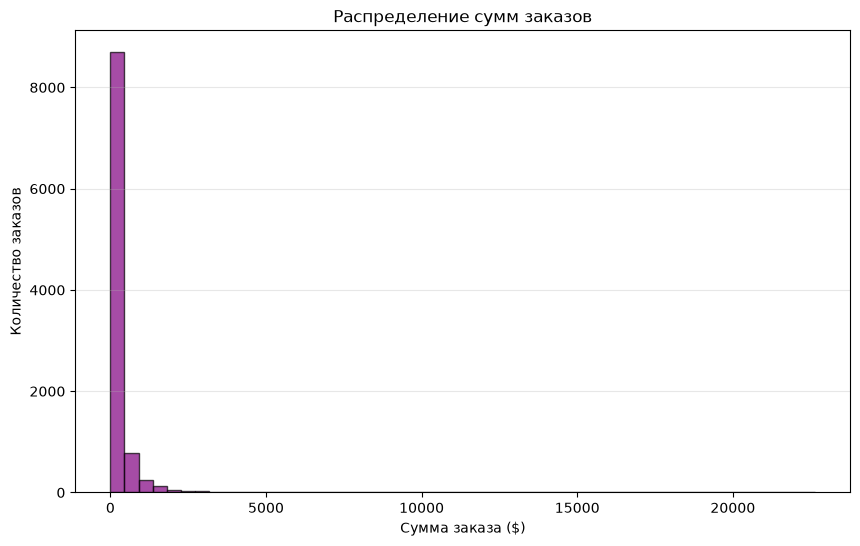

In [88]:
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=50, color='purple', edgecolor='black', alpha=0.7)

plt.title('Распределение сумм заказов')
plt.xlabel('Сумма заказа ($)')
plt.ylabel('Количество заказов')
plt.grid(axis='y', alpha=0.3)

plt.savefig('images/sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [89]:
zero_sales = df[df['Sales'] == 0]
print(f"Заказов с нулевой суммой: {len(zero_sales)}")
print(f"Всего заказов: {len(df)}")
print(f"Процент: {len(zero_sales)/len(df)*100:.2f}%")

Заказов с нулевой суммой: 0
Всего заказов: 9994
Процент: 0.00%


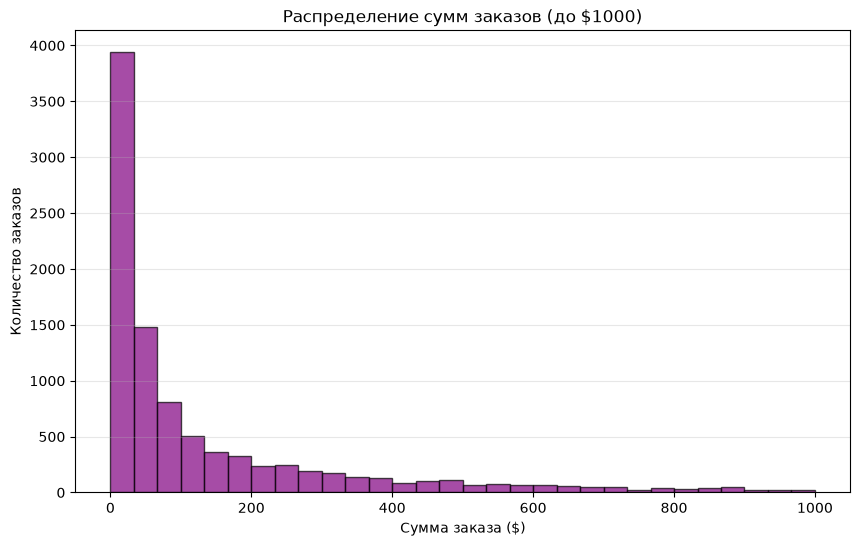

In [90]:
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=30, range=(0, 1000), color='purple', edgecolor='black', alpha=0.7)

plt.title('Распределение сумм заказов (до $1000)')
plt.xlabel('Сумма заказа ($)')
plt.ylabel('Количество заказов')
plt.grid(axis='y', alpha=0.3)

plt.savefig('images/sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

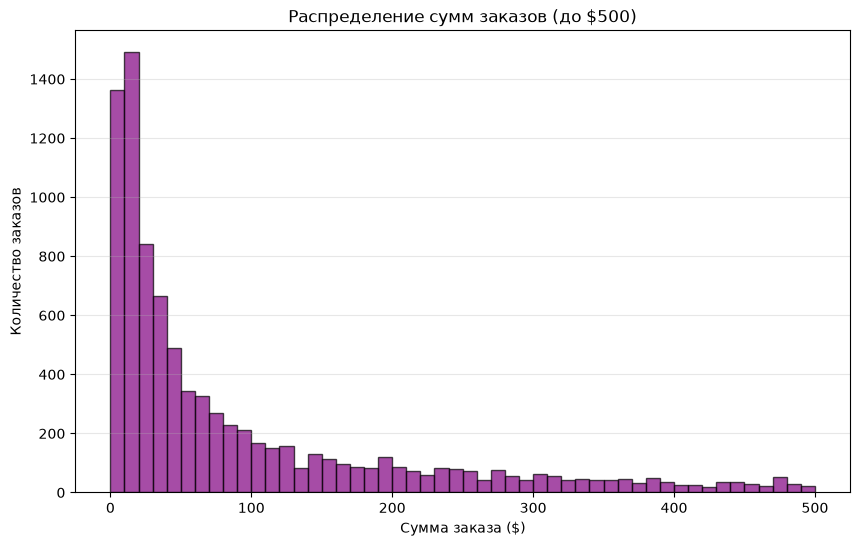

In [91]:
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=50, range=(0, 500), color='purple', edgecolor='black', alpha=0.7)

plt.title('Распределение сумм заказов (до $500)')
plt.xlabel('Сумма заказа ($)')
plt.ylabel('Количество заказов')
plt.grid(axis='y', alpha=0.3)

plt.savefig('images/sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [92]:
df.to_csv('clean_data.csv', index=False)